In [27]:
import json
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

In [28]:
results_df = pd.read_csv(
    "../results/phase3_results.csv"
)

results_df

,split,seed,aggregation,n_classes,spearman
0,55/5,42,mean,5,-0.700000
1,55/5,42,max,5,0.900000
2,48/12,42,mean,12,-0.683116
3,48/12,42,max,12,-0.633819


In [29]:
with open(
    "../results/sadvae_per_class_error_48_12.json",
    "r"
) as f:
    baseline = json.load(f)

with open(
    "../results/groundability_scores_48_12.json",
    "r"
) as f:
    groundability = json.load(f)

In [31]:
groundability_values = []
error_values = []
class_ids = []

for cls in groundability:

    groundability_values.append(
        groundability[cls]["mean"]
    )

    error_values.append(
        baseline[cls]["error"]
    )

    class_ids.append(
        int(cls)
    )

In [32]:
corr, p_value = spearmanr(
    groundability_values,
    error_values
)

print(
    "Spearman:",
    corr
)

print(
    "P-value:",
    p_value
)

Spearman: -0.7042428152039988
P-value: 0.010567247147911846


In [33]:
with open(
    "../data/descriptions.json",
    "r"
) as f:

    descriptions = json.load(f)

class_info = descriptions["classes"]

In [34]:
class_names = []

for cls in class_ids:

    class_names.append(
        class_info[cls]["class_name"]
    )

print(class_names)

['brush hair', 'pick up', 'clapping', 'tear up paper', 'put on a shoe', 'sneeze/cough', 'falling down', 'nausea/vomiting', 'pushing', 'touch pocket', 'walking towards', 'walking apart']


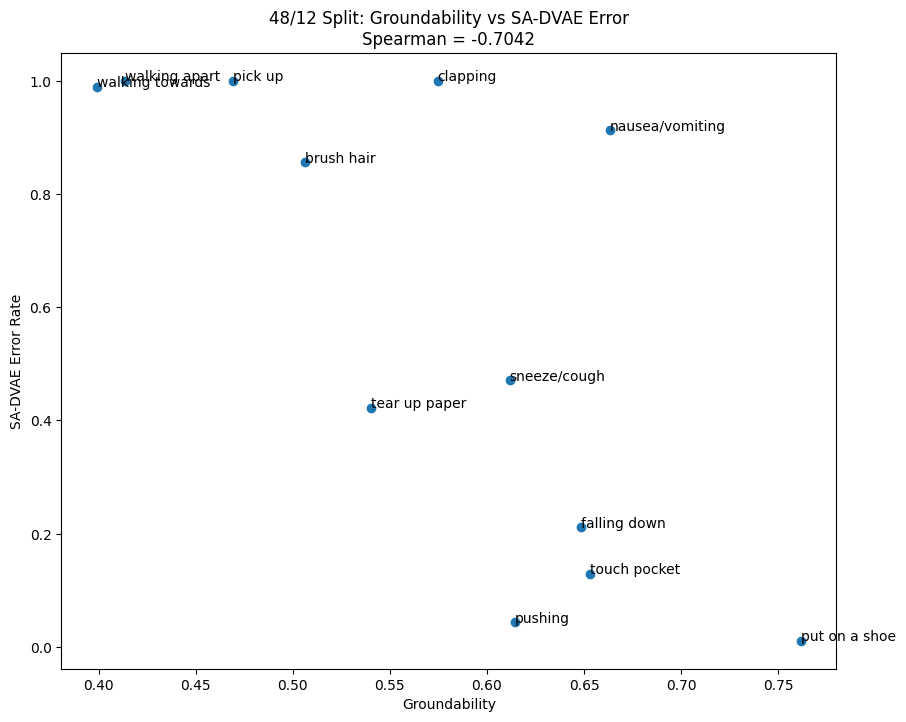

In [35]:
plt.figure(
    figsize=(10,8)
)

plt.scatter(
    groundability_values,
    error_values
)

for i in range(
    len(class_names)
):

    plt.annotate(
        class_names[i],
        (
            groundability_values[i],
            error_values[i]
        )
    )

plt.title(
    f"48/12 Split: Groundability vs SA-DVAE Error\nSpearman = {corr:.4f}"
)

plt.xlabel(
    "Groundability"
)

plt.ylabel(
    "SA-DVAE Error Rate"
)


plt.show()

In [36]:
df = pd.DataFrame(
    {
        "class_id": class_ids,
        "class_name": class_names,
        "groundability": groundability_values,
        "sadvae_error": error_values
    }
)

df

,class_id,class_name,groundability,sadvae_error
0,3,brush hair,0.506172,0.8556
1,5,pick up,0.469263,1.0000
2,9,clapping,0.574620,1.0000
3,12,tear up paper,0.540303,0.4222
4,15,put on a shoe,0.761764,0.0111
5,40,sneeze/cough,0.611654,0.4710
6,42,falling down,0.648460,0.2117
7,47,nausea/vomiting,0.663310,0.9124
8,51,pushing,0.614510,0.0436
9,56,touch pocket,0.653089,0.1296


In [38]:
df.sort_values(
    by=[
        "groundability",
        "sadvae_error"
    ],
    ascending=[
        True,
        False
    ]
)

,class_id,class_name,groundability,sadvae_error
10,58,walking towards,0.398906,0.9889
11,59,walking apart,0.413839,1.0000
1,5,pick up,0.469263,1.0000
0,3,brush hair,0.506172,0.8556
3,12,tear up paper,0.540303,0.4222
2,9,clapping,0.574620,1.0000
5,40,sneeze/cough,0.611654,0.4710
8,51,pushing,0.614510,0.0436
6,42,falling down,0.648460,0.2117
9,56,touch pocket,0.653089,0.1296


## Groundability Analysis Summary

Groundability analysis was conducted on both the 55/5 and 48/12 unseen-class splits using two aggregation strategies: mean aggregation across all body parts and maximum aggregation across body parts. For the 55/5 split, the Spearman correlation between groundability and class error rate was -0.70 using mean aggregation and 0.90 using max aggregation. For the 48/12 split, the Spearman correlation was -0.6831 using mean aggregation and -0.6338 using max aggregation.

The 48/12 split contained 12 unseen classes and was used for the headline scatter plot. Each point in the scatter plot represents one unseen action class, with groundability shown on the x-axis and SA-DVAE per-class error rate shown on the y-axis. Class names were annotated directly on the figure.

Groundability scores for the 48/12 split ranged from approximately 0.40 to 0.76. Error rates ranged from approximately 0.01 to 1.00. The classes appearing in the low-groundability and high-error region of the plot included walking towards (groundability = 0.3989, error = 1.0000), walking apart (0.4138, 1.0000), pick up (0.4693, 1.0000), brush hair (0.5062, 0.7148), and tear up paper (0.5403, 0.9444). At the opposite end, *put on a shoe showed the highest groundability score (0.7618) and a comparatively low error rate (0.0406).